# 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)

# 2. LOAD DATA

In [2]:
df = pd.read_csv("car_maintenance_dataset_expanded.csv")

print("=" * 55)
print(f"  Loaded : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print("=" * 55)
print(df.head())
print()
print("Column types:\n", df.dtypes)
print()
print("Missing values:\n", df.isnull().sum())
print()


  Loaded : 110,000 rows  x  7 columns
   car_id         part  current_km  km_diff  days_diff  needs_change  \
0      21      battery       96160    33520        154             0   
1      36          oil      126032       75        213             0   
2      25        tires      104578    44315        320             0   
3      46      battery      177280    22368        938             0   
4      26  spark_plugs       72819    28827        458             0   

   last_change_km  
0         62640.0  
1             NaN  
2         60263.0  
3        154912.0  
4         43992.0  

Column types:
 car_id              int64
part               object
current_km          int64
km_diff             int64
days_diff           int64
needs_change        int64
last_change_km    float64
dtype: object

Missing values:
 car_id                0
part                  0
current_km            0
km_diff               0
days_diff             0
needs_change          0
last_change_km    10000
dtype: int6

# 3. CLEAN DATA




In [3]:
df = df[(df["km_diff"] >= 0) & (df["days_diff"] > 0)]

# 4. FEATURE ENGINEERING


In [4]:
df = pd.get_dummies(df, columns=["part"])

# 5. FEATURES & TARGET



In [5]:
FEATURES = [
    "km_diff",
    "days_diff",
    "current_km"
] + [col for col in df.columns if col.startswith("part_")]

X = df[FEATURES]
y = df["needs_change"]

print("Feature shape:", X.shape)

Feature shape: (110000, 16)


# 6. TRAIN / TEST SPLIT




In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 7. CROSS-VALIDATION (BASELINE)



In [7]:
baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

cv_f1 = cross_val_score(baseline, X_train, y_train, cv=5, scoring="f1")

print(f"CV F1 Score: {cv_f1.mean():.4f}")

CV F1 Score: 0.8347


# 8. HYPERPARAMETER TUNING



In [8]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [8, 12, None],
    "min_samples_split": [2, 5],
    "class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
model1 = grid.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


# 9. EVALUATE ON TEST SET




In [9]:
y_pred = model1.predict(X_test)
y_prob = model1.predict_proba(X_test)[:, 1]

print("\n=== FINAL RESULTS ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



=== FINAL RESULTS ===
Accuracy: 0.8847272727272727
ROC-AUC: 0.8846150802253722

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.93      0.91     14029
           1       0.87      0.80      0.83      7971

    accuracy                           0.88     22000
   macro avg       0.88      0.87      0.87     22000
weighted avg       0.88      0.88      0.88     22000



# 10. CONFUSION MATRIX



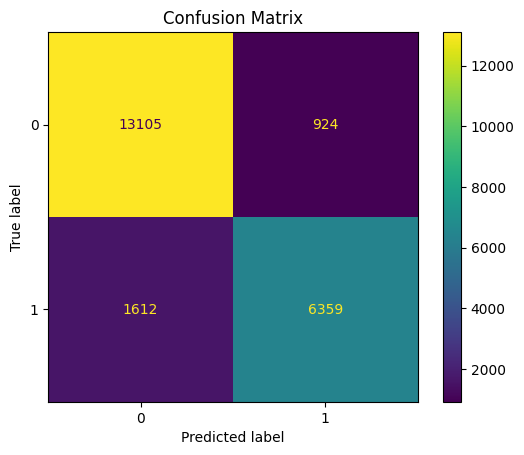

In [10]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()


# 11. ROC CURVE

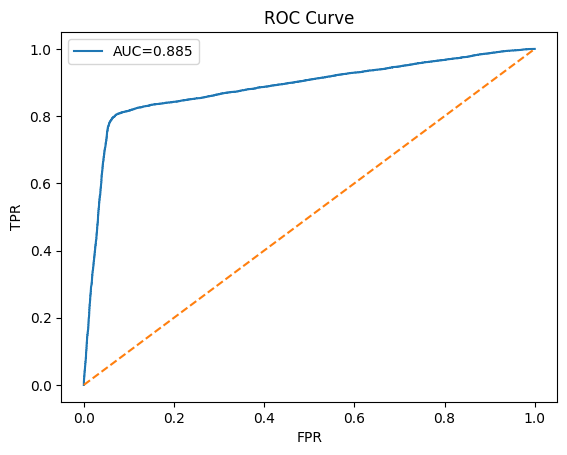

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 12. FEATURE IMPORTANCE



In [12]:
importances = model1.feature_importances_

feat_imp = pd.DataFrame({
    "feature": FEATURES,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop Features:\n", feat_imp.head(10))


Top Features:
              feature  importance
0            km_diff    0.471577
1          days_diff    0.251168
2         current_km    0.139205
10          part_oil    0.025076
14        part_tires    0.023885
4       part_battery    0.017496
3    part_air_filter    0.017254
9   part_fuel_filter    0.016531
11  part_spark_plugs    0.016097
8    part_brake_pads    0.015079


# 13. SAVE MODEL

In [13]:
joblib.dump(model1, "need_maintainance.pkl")

print("\n✅ Model saved as model1_clean.pkl")


✅ Model saved as model1_clean.pkl






# 14. PREDICTION FUNCTION 






In [14]:
def predict(part, km_diff, days_diff, current_km):

    # build input row
    row = {f: 0 for f in FEATURES}

    row["km_diff"] = km_diff
    row["days_diff"] = days_diff
    row["current_km"] = current_km

    # activate correct part column
    part_col = f"part_{part}"
    if part_col in row:
        row[part_col] = 1

    sample = pd.DataFrame([row])

    pred = model1.predict(sample)[0]
    prob = model1.predict_proba(sample)[0][1]

    return pred, prob

# 15. SAMPLE PREDICTIONS 

In [15]:
print("\n=== SAMPLE TEST ===")

pred, prob = predict("brake_pads", 25000, 200, 90000)

print("Prediction:", pred)
print("Confidence:", prob)


=== SAMPLE TEST ===
Prediction: 1
Confidence: 0.9250691175197191
